In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/Historic-Data-20th-20th.csv")

In [77]:
# df = df.loc[~df["symbol"].isin(df.loc[(df["close"] < 5) & (df["report_date"] == df.groupby('symbol')['report_date'].transform('min'))]["symbol"]),:]

In [78]:
# df.loc[df["symbol"].isin(df.loc[(df["close"] < 4.65) & (df["report_date"] == "2019-01-02")]["symbol"]),:]["symbol"].unique()

In [79]:
df.to_csv("data/InflAdj_Data_2019_2025_more_than_five.csv")

In [80]:
df = df.loc[:, ["report_date", "close (%)"]].groupby("report_date").mean()

In [81]:
df.loc[df["close (%)"] < 0,:]

,close (%)
report_date,
2019-01-03,-1.021930
2020-03-09,-1.962035
2020-03-11,-5.033762
2020-03-12,-15.159053
2020-03-13,-10.476033
2020-03-16,-20.929648
2020-03-17,-17.685516
2020-03-18,-26.279622
2020-03-19,-22.490293


Line will not start in the centre, because then we can't do negative values, instead start a set distance from the centre, probably one so that we avoid negative values from crossing the centre

In [82]:
df.reset_index(inplace=True)

In [83]:
df["report_date"] = pd.to_datetime(df["report_date"])
df

,report_date,close (%)
0,2019-01-02,0.000000
1,2019-01-03,-1.021930
2,2019-01-04,2.026178
3,2019-01-07,3.627805
4,2019-01-08,4.720220
...,...,...
1823,2026-04-06,41.653912
1824,2026-04-07,41.619121
1825,2026-04-08,45.488933
1826,2026-04-09,46.551387


In [84]:
df['month'] = pd.DatetimeIndex(df['report_date']).month
df["day"] = pd.DatetimeIndex(df['report_date']).day

In [85]:
month_to_degree = {m: (m - 1) * 30 for m in range(1, 13)}
df["month_rotation"] = df["month"].map(month_to_degree.get)

In [86]:
# 2. Convert report_date to datetime if not already
df['report_date'] = pd.to_datetime(df['report_date'])
df['year'] = df['report_date'].dt.year

# 3. Calculate min and max day for each month per year
# We group by year and month to handle the "dynamic" nature of banking days
month_bounds = df.groupby(['year', 'month'])['day'].agg(['min', 'max']).reset_index()
month_bounds.rename(columns={'min': 'min_day', 'max': 'max_day'}, inplace=True)

# 4. Merge these bounds back into the main dataframe
df = df.merge(month_bounds, on=['year', 'month'])

# 5. Calculate the rotation
# (day - min) / (max - min) gives a value between 0 and 1
# We use .fillna(0) for cases where a month might only have 1 data point
df['day_progress'] = (df['day'] - df['min_day']) / (df['max_day'] - df['min_day']).replace(0, 1)
df['day_degrees'] = df['month'].map(month_to_degree) + (df['day_progress'] * 30)

# Cleanup (optional)
df = df.drop(columns=['min_day', 'max_day', 'day_progress'])

In [87]:
shift_zero = abs(df["close (%)"].min())
df["distance_from_center"] = df["close (%)"] + shift_zero

In [88]:
from numpy import cos, sin, radians
df["x"] = df["distance_from_center"] * sin(radians(df["day_degrees"]))
df["y"] = df["distance_from_center"] * cos(radians(df["day_degrees"]))

In [89]:
df

,report_date,close (%),month,day,month_rotation,year,day_degrees,distance_from_center,x,y
0,2019-01-02,0.000000,1,2,0,2019,0.000000,26.279622,0.000000,26.279622
1,2019-01-03,-1.021930,1,3,0,2019,1.034483,25.257692,0.456006,25.253575
2,2019-01-04,2.026178,1,4,0,2019,2.068966,28.305800,1.021908,28.287347
3,2019-01-07,3.627805,1,7,0,2019,5.172414,29.907427,2.696247,29.785642
4,2019-01-08,4.720220,1,8,0,2019,6.206897,30.999842,3.351672,30.818120
...,...,...,...,...,...,...,...,...,...,...
1823,2026-04-06,41.653912,4,6,90,2026,106.666667,67.933534,65.079613,-19.483557
1824,2026-04-07,41.619121,4,7,90,2026,110.000000,67.898742,63.803947,-23.222738
1825,2026-04-08,45.488933,4,8,90,2026,113.333333,71.768554,65.899043,-28.426072
1826,2026-04-09,46.551387,4,9,90,2026,116.666667,72.831008,65.084166,-32.686497


In [90]:
df["cont_time"] = df.index

(np.float64(-87.90242142725215),
 np.float64(91.32061452476415),
 np.float64(-91.74709718718645),
 np.float64(82.60735353612506))

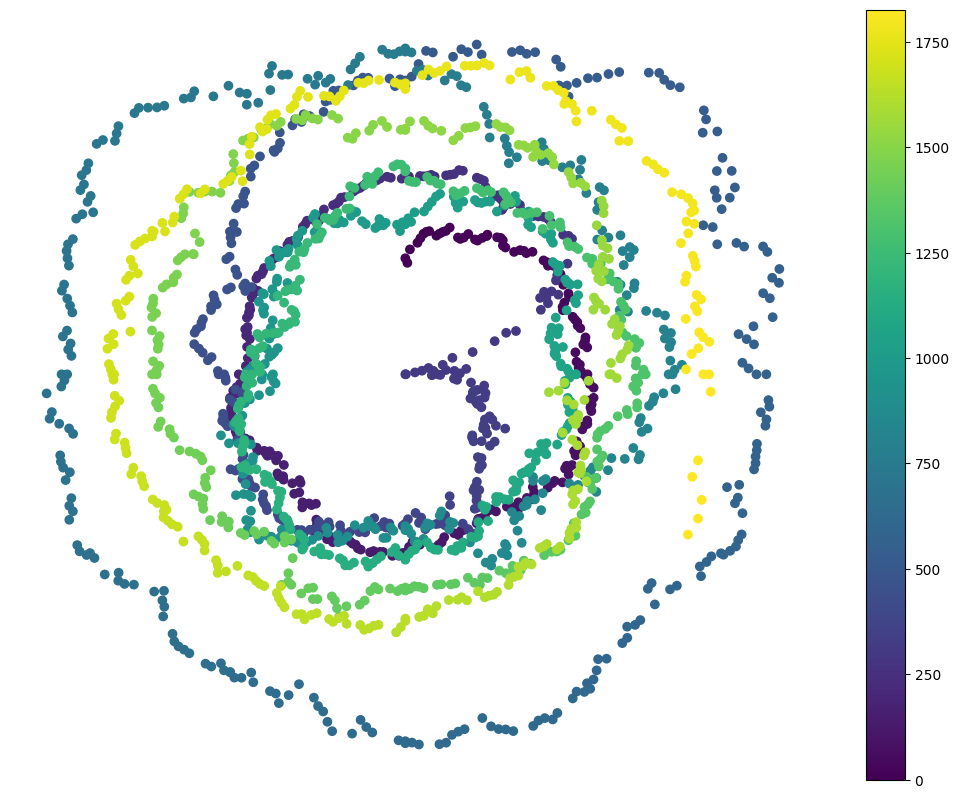

In [91]:
plt.figure(figsize=(13,10))
plt.scatter(df["x"], df["y"], c = df["cont_time"])
plt.colorbar()
plt.axis("off")

In [92]:
df

,report_date,close (%),month,day,month_rotation,year,day_degrees,distance_from_center,x,y,cont_time
0,2019-01-02,0.000000,1,2,0,2019,0.000000,26.279622,0.000000,26.279622,0
1,2019-01-03,-1.021930,1,3,0,2019,1.034483,25.257692,0.456006,25.253575,1
2,2019-01-04,2.026178,1,4,0,2019,2.068966,28.305800,1.021908,28.287347,2
3,2019-01-07,3.627805,1,7,0,2019,5.172414,29.907427,2.696247,29.785642,3
4,2019-01-08,4.720220,1,8,0,2019,6.206897,30.999842,3.351672,30.818120,4
...,...,...,...,...,...,...,...,...,...,...,...
1823,2026-04-06,41.653912,4,6,90,2026,106.666667,67.933534,65.079613,-19.483557,1823
1824,2026-04-07,41.619121,4,7,90,2026,110.000000,67.898742,63.803947,-23.222738,1824
1825,2026-04-08,45.488933,4,8,90,2026,113.333333,71.768554,65.899043,-28.426072,1825
1826,2026-04-09,46.551387,4,9,90,2026,116.666667,72.831008,65.084166,-32.686497,1826


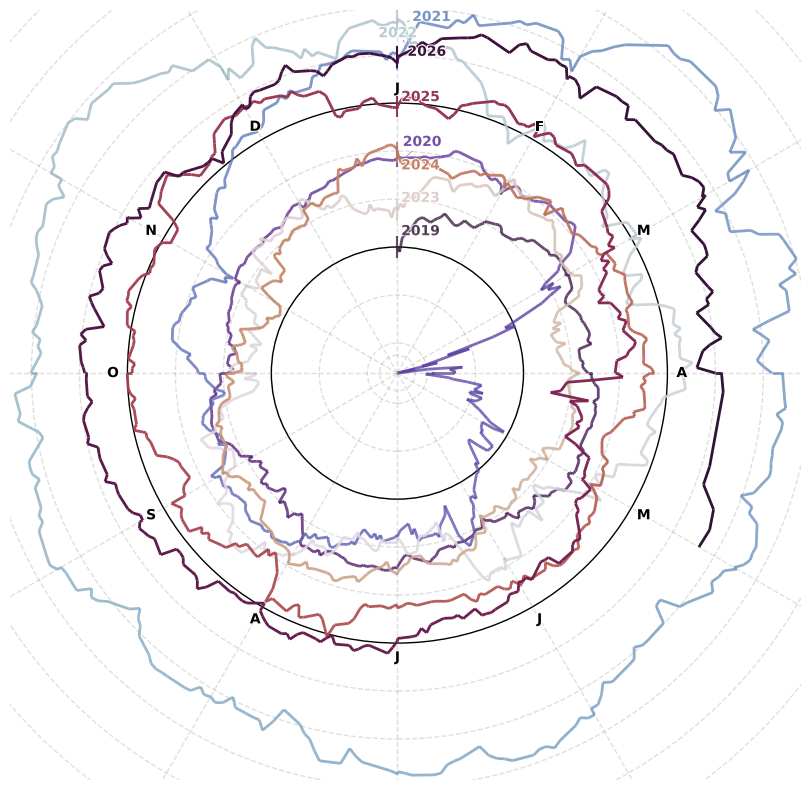

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from adjustText import adjust_text
import matplotlib.patheffects as path_effects

# 1. Generate sample data (a spiral)
x = df["x"]
y = df["y"]
z = df["cont_time"]  # The values used for coloring

TICKLINE_ALPHA = 0.25

# 2. Prepare the segments (reshape points into[N, 1, 2] array)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 2. Setup the colormap and normalization
cmap = plt.get_cmap('twilight_shifted') # Ensure this matches your LineCollection
norm = plt.Normalize(df['cont_time'].min(), df['cont_time'].max())

# 3. Create the LineCollection
fig, ax = plt.subplots()
fig.set_figheight(10)
fig.set_figwidth(13)

def scale_to_range(arr, new_min=0.5, new_max=1.0):
    arr = np.array(arr)
    # Calculate min and max of the input array
    old_min = arr.min()
    old_max = arr.max()
    
    # Avoid division by zero if all values are the same
    if old_max == old_min:
        return np.full_like(arr, (new_min + new_max) / 2)
    
    # Apply the formula
    return new_min + (arr - old_min) * (new_max - new_min) / (old_max - old_min)

rgba_values = cmap(norm(df['cont_time']))
rgba_values[:, 3] = scale_to_range(df['cont_time'], new_min=0.75, new_max=1)

# lc = LineCollection(segments, cmap=cmap, norm=norm)
lc = LineCollection(segments, colors=rgba_values)
# lc.set_array(z)
lc.set_linewidth(2)

# 4. Add to plot
line = ax.add_collection(lc)
# fig.colorbar(line, ax=ax)
ax.set_xlim(x.min()-1, x.max()+1)
ax.set_ylim(y.min()-1, y.max()+1)


# 4. Annotate the first occurrence of each year
# Find the index of the first row for every unique year
first_year_indices = df.drop_duplicates(subset='year', keep='first').index

texts = list()

for idx in first_year_indices:
    year = df.loc[idx, 'year']
    val = df.loc[idx, 'cont_time']
    x_pos = df.loc[idx, 'x']
    x_pos_text = df.loc[idx, 'x']+1.5
    y_pos = df.loc[idx, 'y']
    y_pos_text= df.loc[idx+3, 'y']
    alpha = rgba_values[:, 3][idx]

    point_color = cmap(norm(val))

    tick_length = 4
    ax.plot([x_pos, x_pos],[y_pos - tick_length/2, y_pos + tick_length/2], 
            color=point_color, lw=1.5, zorder=10, alpha=alpha)
    
    t = ax.text(
        x_pos_text, y_pos_text, 
        str(year), 
        color=point_color,
        fontsize=10, 
        fontweight='bold',
        alpha=alpha
    )

    # Add the outline (Stroke) and the original text (Normal)
    t.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


# 1. Calculate the maximum distance to determine the scale
max_dist = df['distance_from_center'].max()

angles = list(month_to_degree.values())


def rotate_vector(vector, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    return vector @ R.T


# 2. Define the radii for your concentric circles
# We want circles at 20%, 40%, 60%, 80%, and 100% of the maximum radius
bar_spacing_percent = 10
radii = np.arange(-round(shift_zero,-1), round(max_dist, -1), bar_spacing_percent) + shift_zero

# Loop through each angle to plot individual lines, the "axis" lines
month_texts = []
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ring_num = -6

for i, angle in enumerate(angles):
    # 1. Define the start (center) and end point
    start_point = np.array([0, 0])
    end_point = rotate_vector(np.array([0, radii[-1]+2]), -angle)
    
    # 2. Plot the line
    # X coordinates:[start_x, end_x], Y coordinates: [start_y, end_y]
    ax.plot([start_point[0], end_point[0]], 
            [start_point[1], end_point[1]], 
            color='grey', alpha=TICKLINE_ALPHA, lw=1, linestyle="--")
    
    text_point = rotate_vector(np.array([0, radii[ring_num]+3]), -angle)
    
    t = ax.text(
        text_point[0], text_point[1], 
        str(months[i]), 
        color="black",
        fontsize=10, 
        fontweight='bold',
        alpha=alpha,
        ha='center',
        va='center',
    )
    t.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])
    month_texts.append(t)
    
# 3. Add circles to the plot
for i, r in enumerate(radii):
    if r == radii[ring_num]:
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color='black',       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle='-',     # Dashed line style
            linewidth=1,        # Thickness of the ring
            alpha=1,          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)
    else:
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color='grey',       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle='--',     # Dashed line style
            linewidth=1,        # Thickness of the ring
            alpha=TICKLINE_ALPHA,          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)
# 3.1. Add zero circle to plot
circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            shift_zero,         # Radius
            color='black',      # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle='-',      # Normal line style
            linewidth=1,        # Thickness of the ring
            alpha=1,          # Transparency
            zorder=0            # Put behind the data line
        )
ax.add_patch(circle)

# 5. Final adjustments
ax.autoscale_view()
ax.set_aspect('equal') # Important for spiral/radial plots
ax.axis('off') 
# ax.set_xlim(xmin=-radii[-1], xmax=radii[-1])
# ax.set_ylim(ymin=-radii[-1], ymax=radii[-1])
plt.show()


In [94]:
fig.savefig("figs/spiral_test_2.png", dpi=300, bbox_inches="tight")
fig.savefig("figs/spiral_test_2.pdf", bbox_inches="tight")